SoVI tracts loaded: 1471
RUCA tracts for state 47: 1701
Crosswalked RUCA tracts: 1493
  Urban (1-3): 1084 | Rural (4-10): 409
Merged tracts: 1467


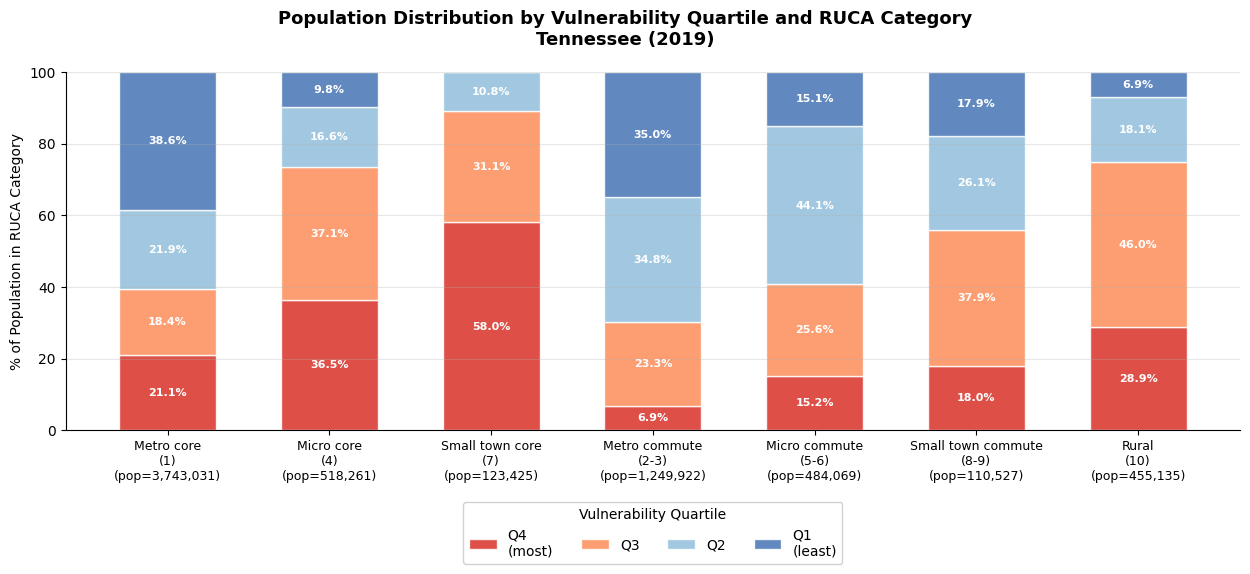

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Tennessee.gpkg"
STATE_FIPS = "47"
TITLE      = "Tennessee"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SoVI tracts loaded: 654
RUCA tracts for state 28: 878
Crosswalked RUCA tracts: 659
  Urban (1-3): 290 | Rural (4-10): 369
Merged tracts: 650


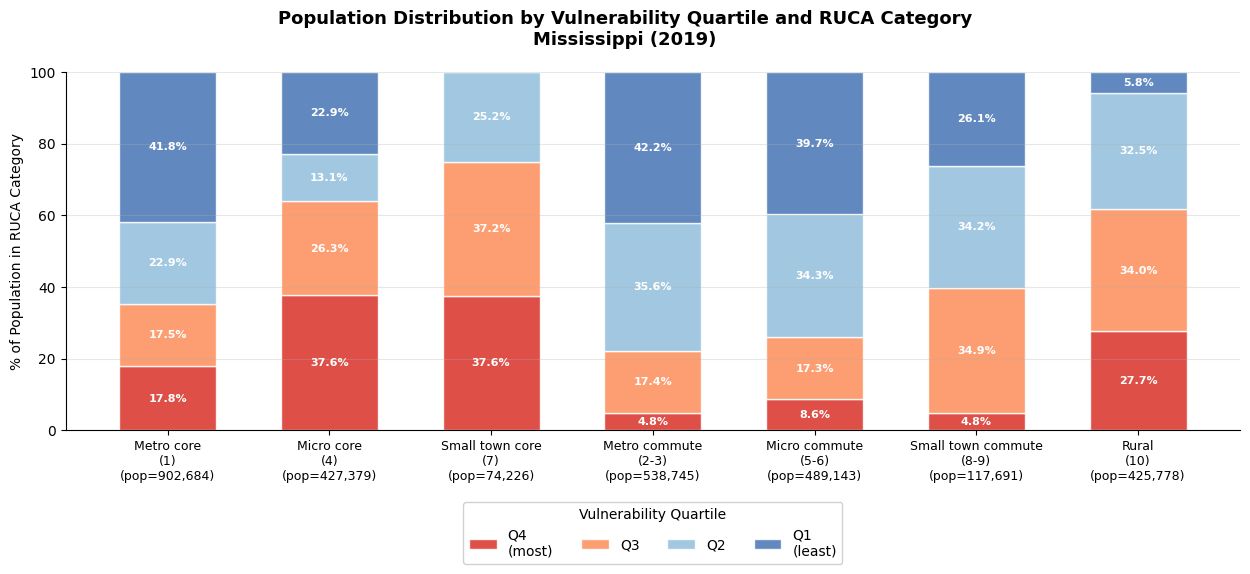

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Mississippi.gpkg"
STATE_FIPS = "28"
TITLE      = "Mississippi"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SoVI tracts loaded: 1174
RUCA tracts for state 01: 1437
Crosswalked RUCA tracts: 1177
  Urban (1-3): 850 | Rural (4-10): 327
Merged tracts: 1170


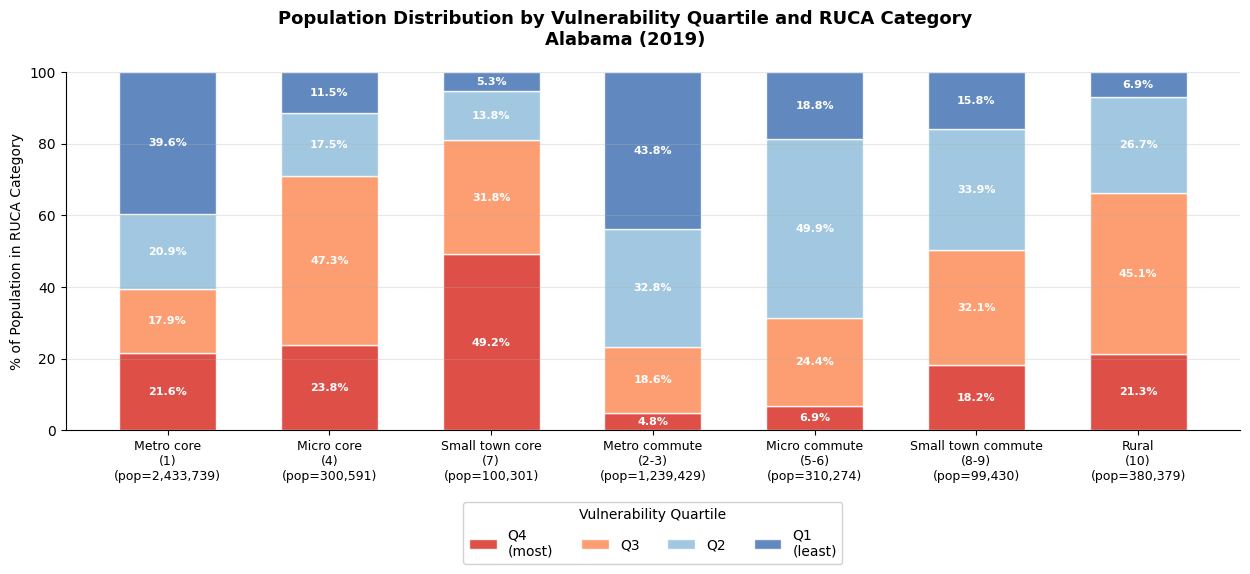

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Alabama.gpkg"
STATE_FIPS = "01"
TITLE      = "Alabama"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SoVI tracts loaded: 1385
RUCA tracts for state 29: 1654
Crosswalked RUCA tracts: 1390
  Urban (1-3): 973 | Rural (4-10): 417
Merged tracts: 1382


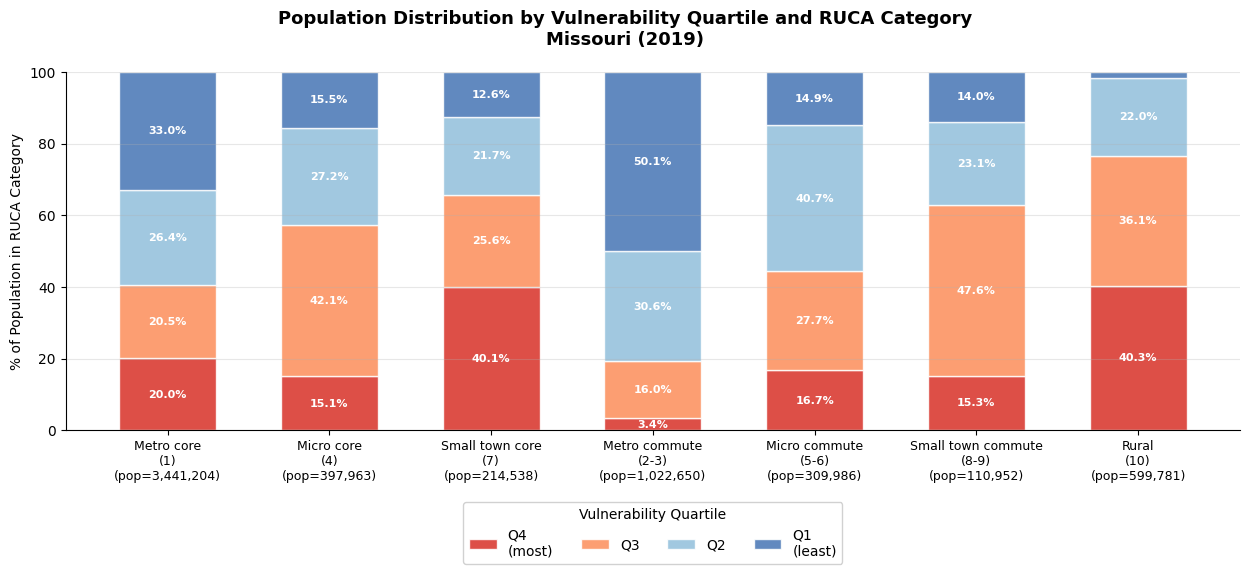

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Missouri.gpkg"
STATE_FIPS = "29"
TITLE      = "Missouri"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SoVI tracts loaded: 1952
RUCA tracts for state 13: 2796
Crosswalked RUCA tracts: 1960
  Urban (1-3): 1525 | Rural (4-10): 435
Merged tracts: 1945


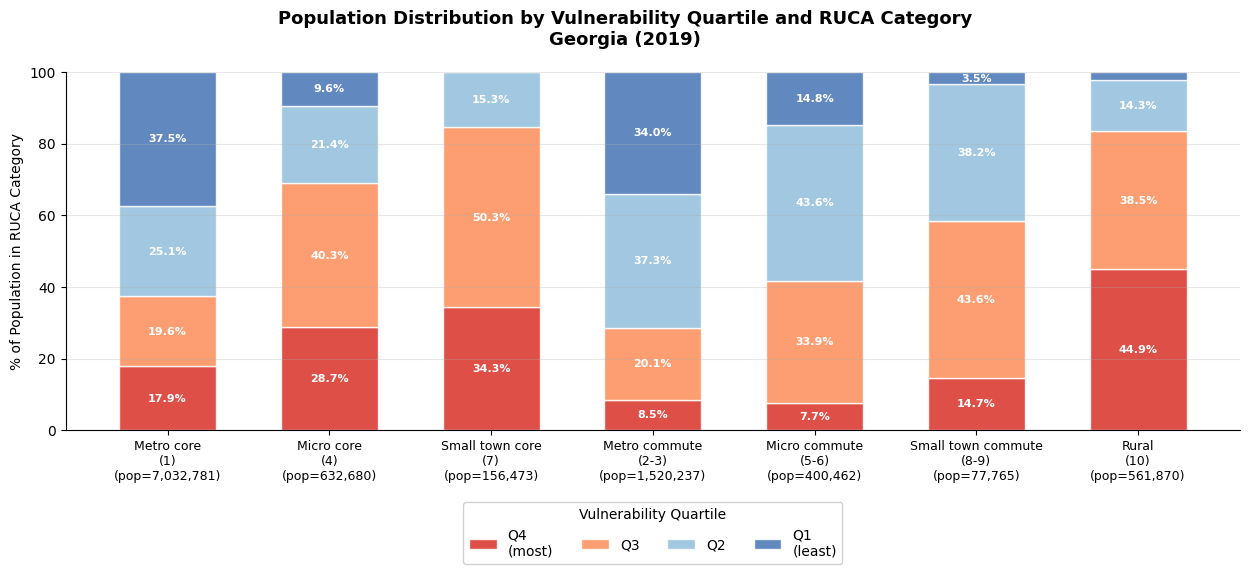

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Georgia.gpkg"
STATE_FIPS = "13"
TITLE      = "Georgia"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

SoVI tracts loaded: 683
RUCA tracts for state 05: 823
Crosswalked RUCA tracts: 684
  Urban (1-3): 362 | Rural (4-10): 322
Merged tracts: 681


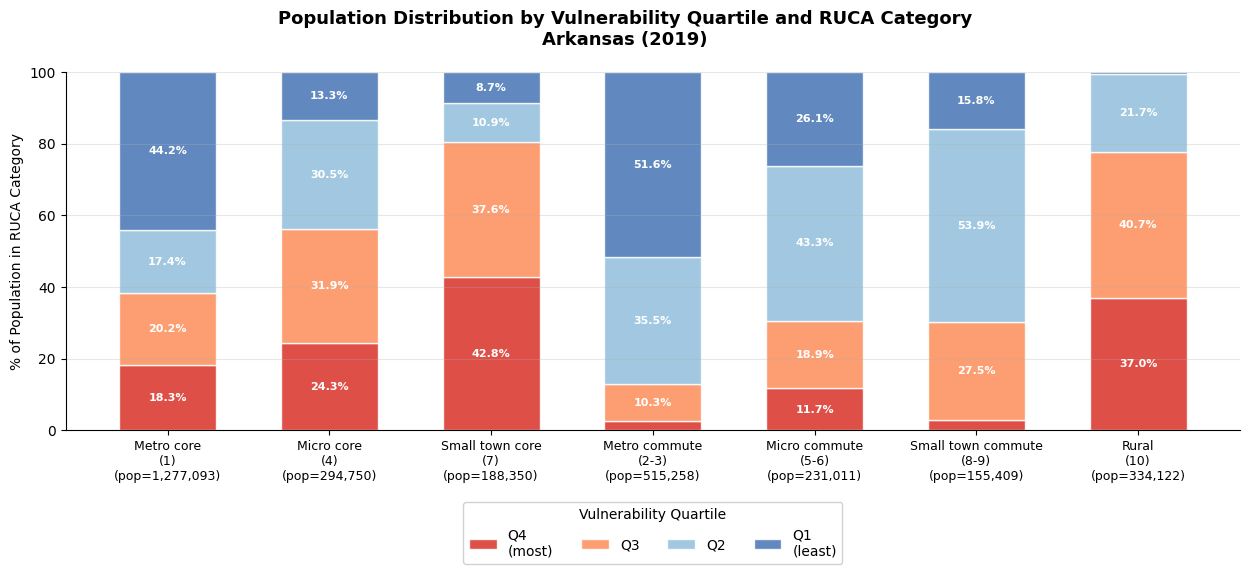

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io
import geopandas as gpd

# ==============================================================================
# USER CONFIG — edit these for each state
# ==============================================================================
SOVI_PATH  = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V3/results/K-SoVI_UMAP_2019_Arkansas.gpkg"
STATE_FIPS = "05"
TITLE      = "Arkansas"

RUCA_CATEGORY_ORDER = [
    "Metro core\n(1)",
    "Micro core\n(4)",
    "Small town core\n(7)",
    "Metro commute\n(2-3)",
    "Micro commute\n(5-6)",
    "Small town commute\n(8-9)",
    "Rural\n(10)",
]

# ==============================================================================
# LOAD SOVI
# ==============================================================================
sovi = gpd.read_file(SOVI_PATH)
sovi["GEOID"] = sovi["GEOID"].astype(str).str.zfill(11)
df = pd.DataFrame(sovi.drop(columns="geometry"))

# Normalize column name
for col in ["SoVI_Score_Weighted_x", "SoVI_Score_Weighted_y", "SoVI_Score_Weighted"]:
    if col in df.columns:
        df = df.rename(columns={col: "SoVI_Score_Weighted"})
        break

df = df.dropna(subset=["SoVI_Score_Weighted", "TOTALPOP"])
print(f"SoVI tracts loaded: {len(df)}")

# ==============================================================================
# DOWNLOAD RUCA 2020 (tract level)
# ==============================================================================
print("Downloading 2020 RUCA codes...")
RUCA_URL = "https://www.ers.usda.gov/media/5443/2020-rural-urban-commuting-area-codes-census-tracts.csv?v=24674"
r = requests.get(RUCA_URL, timeout=120)
try:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("utf-8")), dtype=str)
except UnicodeDecodeError:
    ruca_all = pd.read_csv(io.StringIO(r.content.decode("latin1")), dtype=str)
ruca_all["GEOID20"] = ruca_all["TractFIPS20"].astype(str).str.zfill(11)
ruca_all["PrimaryRUCA"] = pd.to_numeric(ruca_all["PrimaryRUCA"], errors="coerce")
ruca_state = ruca_all[ruca_all["GEOID20"].str.startswith(STATE_FIPS)][["GEOID20", "PrimaryRUCA"]].dropna()
print(f"RUCA tracts for state {STATE_FIPS}: {len(ruca_state)}")

# ==============================================================================
# CROSSWALK RUCA 2020 → 2010 TRACTS
# ==============================================================================
print("Downloading 2010-2020 tract relationship file...")
REL_URL = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/tract/tab20_tract20_tract10_natl.txt"
r = requests.get(REL_URL, timeout=180)
try:
    rel = pd.read_csv(io.StringIO(r.content.decode("utf-8")), sep="|", dtype=str)
except UnicodeDecodeError:
    rel = pd.read_csv(io.StringIO(r.content.decode("latin1")), sep="|", dtype=str)
rel["GEOID_TRACT_20"] = rel["GEOID_TRACT_20"].str.zfill(11)
rel["GEOID_TRACT_10"] = rel["GEOID_TRACT_10"].str.zfill(11)
rel_state = rel[rel["GEOID_TRACT_10"].str.startswith(STATE_FIPS)].copy()
rel_state["AREALAND_PART"] = pd.to_numeric(rel_state["AREALAND_PART"], errors="coerce")

best_match = rel_state.sort_values("AREALAND_PART", ascending=False)\
                      .drop_duplicates(subset="GEOID_TRACT_20", keep="first")\
                      [["GEOID_TRACT_20", "GEOID_TRACT_10"]]

ruca_xw = ruca_state.merge(best_match, left_on="GEOID20", right_on="GEOID_TRACT_20", how="left")
ruca_xw = ruca_xw[["GEOID_TRACT_10", "PrimaryRUCA"]].rename(columns={"GEOID_TRACT_10": "GEOID"}).dropna()
ruca_final = ruca_xw.groupby("GEOID")["PrimaryRUCA"]\
             .agg(lambda x: x.mode().iloc[0]).reset_index()
print(f"Crosswalked RUCA tracts: {len(ruca_final)}")
print(f"  Urban (1-3): {(ruca_final['PrimaryRUCA'] <= 3).sum()} | Rural (4-10): {(ruca_final['PrimaryRUCA'] > 3).sum()}")

# ==============================================================================
# MERGE
# ==============================================================================
df = df.merge(ruca_final, on="GEOID", how="inner")
df = df.dropna(subset=["PrimaryRUCA", "SoVI_Score_Weighted", "TOTALPOP"])
print(f"Merged tracts: {len(df)}")

# ==============================================================================
# VULNERABILITY QUARTILES
# ==============================================================================
df["vuln_q"] = pd.qcut(df["SoVI_Score_Weighted"], 4,
                        labels=["Q1\n(least)", "Q2", "Q3", "Q4\n(most)"])
vuln_order  = ["Q4\n(most)", "Q3", "Q2", "Q1\n(least)"]
colors_list = ["#d73027", "#fc8d59", "#91bfdb", "#4575b4"]

# ==============================================================================
# RUCA BINS
# ==============================================================================
ruca_bins = {
    "Metro core\n(1)":           (1, 1),
    "Metro commute\n(2-3)":      (2, 3),
    "Micro core\n(4)":           (4, 4),
    "Micro commute\n(5-6)":      (5, 6),
    "Small town core\n(7)":      (7, 7),
    "Small town commute\n(8-9)": (8, 9),
    "Rural\n(10)":               (10, 10),
}

RUCA_CATEGORY_ORDER = [c for c in RUCA_CATEGORY_ORDER
                       if df["PrimaryRUCA"].between(*ruca_bins[c]).any()]

# ==============================================================================
# BUILD DATA
# ==============================================================================
ruca_labels = []
data_matrix = []

for bin_label in RUCA_CATEGORY_ORDER:
    lo, hi = ruca_bins[bin_label]
    sub = df[(df["PrimaryRUCA"] >= lo) & (df["PrimaryRUCA"] <= hi)].copy()
    total_pop   = sub["TOTALPOP"].sum()
    pop_by_vuln = sub.groupby("vuln_q")["TOTALPOP"].sum()
    pcts = [pop_by_vuln.get(g, 0) / total_pop * 100 if total_pop > 0 else 0
            for g in vuln_order]
    ruca_labels.append(f"{bin_label}\n(pop={total_pop:,.0f})")
    data_matrix.append(pcts)

data_matrix = list(zip(*data_matrix))

# ==============================================================================
# PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(max(12, len(RUCA_CATEGORY_ORDER) * 1.8), 6))
x      = range(len(ruca_labels))
bottom = [0] * len(ruca_labels)

for i, (quartile, color) in enumerate(zip(vuln_order, colors_list)):
    values = data_matrix[i]
    bars = ax.bar(x, values, bottom=bottom, color=color, alpha=0.85,
                  edgecolor="white", width=0.6, label=quartile)
    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bottom[j] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(x)
ax.set_xticklabels(ruca_labels, fontsize=9)
ax.set_ylabel("% of Population in RUCA Category", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Vulnerability Quartile", loc="upper center",
          bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)

plt.suptitle(f"Population Distribution by Vulnerability Quartile and RUCA Category\n{TITLE} (2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()